# 02 — Feature Engineering

Builds the **unified multilingual dataset** with engineered features.

## What this notebook does:
1. Loads the UCI English dataset
2. Loads Hindi/Bengali datasets (HuggingFace) — or documents fallback
3. Combines into a unified schema: `[text, label, language, is_augmented]`
4. Applies `src/preprocess.process_dataframe()` to add all engineered features
5. Performs the 70/15/15 stratified train/val/test split
6. Saves processed splits to `data/`

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from src.preprocess import process_dataframe, engineer_features

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

sns.set_theme(style='darkgrid')
print('Ready.')

Ready.


## 1. Load English (UCI)

In [2]:
df_en = pd.read_csv('../dataset/Spam SMS Collection', sep='\t',
                    names=['label', 'text'], encoding='latin-1')
df_en['label']        = (df_en['label'] == 'spam').astype(int)
df_en['language']     = 'en'
df_en['is_augmented'] = False

# Drop duplicates from original dataset
df_en = df_en.drop_duplicates(subset='text').reset_index(drop=True)

print(f'English samples: {len(df_en)} (SPAM={df_en.label.sum()}, HAM={(~df_en.label.astype(bool)).sum()})')
df_en.head(3)

English samples: 5169 (SPAM=653, HAM=4516)


,label,text,language,is_augmented
0,0,"Go until jurong point, crazy.. Available only ...",en,False
1,0,Ok lar... Joking wif u oni...,en,False
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,en,False


## 2. Load Hindi Dataset

We attempt to load from HuggingFace. If unavailable, we document the fallback.

In [3]:
df_hi = None

try:
    from datasets import load_dataset
    # Attempt primary source — AI4Bharat Hindi SMS Spam
    ds = load_dataset('ai4bharat/IndicNLP-Hindi-SMS-Spam', split='train', trust_remote_code=True)
    df_hi = ds.to_pandas().rename(columns={'message': 'text', 'category': 'label'})
    df_hi['label']        = (df_hi['label'].str.lower() == 'spam').astype(int)
    df_hi['language']     = 'hi'
    df_hi['is_augmented'] = False
    print(f'Hindi (HuggingFace): {len(df_hi)} samples')
except Exception as e:
    print(f'Hindi HuggingFace load failed: {e}')
    print('FALLBACK: Hindi samples will be generated via IndicTrans2 in notebook 03.')
    print('is_augmented will be set to True for those samples.')

print(df_hi.head(3) if df_hi is not None else 'No Hindi data loaded at this stage.')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/IndicNLP-Hindi-SMS-Spam' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Hindi HuggingFace load failed: Dataset 'ai4bharat/IndicNLP-Hindi-SMS-Spam' doesn't exist on the Hub or cannot be accessed.
FALLBACK: Hindi samples will be generated via IndicTrans2 in notebook 03.
is_augmented will be set to True for those samples.
No Hindi data loaded at this stage.


## 3. Load Bengali Dataset

In [4]:
df_bn = None

try:
    from datasets import load_dataset
    ds = load_dataset('ai4bharat/IndicNLP-Bengali-SMS-Spam', split='train', trust_remote_code=True)
    df_bn = ds.to_pandas().rename(columns={'message': 'text', 'category': 'label'})
    df_bn['label']        = (df_bn['label'].str.lower() == 'spam').astype(int)
    df_bn['language']     = 'bn'
    df_bn['is_augmented'] = False
    print(f'Bengali (HuggingFace): {len(df_bn)} samples')
except Exception as e:
    print(f'Bengali HuggingFace load failed: {e}')
    print('FALLBACK: Bengali samples will be generated via IndicTrans2 in notebook 03.')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/IndicNLP-Bengali-SMS-Spam' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Bengali HuggingFace load failed: Dataset 'ai4bharat/IndicNLP-Bengali-SMS-Spam' doesn't exist on the Hub or cannot be accessed.
FALLBACK: Bengali samples will be generated via IndicTrans2 in notebook 03.


## 4. Assamese samples come from notebook 03 (augmentation)
They are loaded here if the augmentation notebook has already been run.

In [5]:
df_as = None
augmented_path = DATA_DIR / 'assamese_augmented.csv'

if augmented_path.exists():
    df_as = pd.read_csv(augmented_path)
    print(f'Assamese augmented samples loaded: {len(df_as)}')
    print(df_as['label'].value_counts())
else:
    print('Assamese augmented data not found. Run notebook 03 first, then rerun this cell.')

Assamese augmented data not found. Run notebook 03 first, then rerun this cell.


## 5. Combine into unified schema

In [6]:
# Build list of available DataFrames
dfs = [df_en]
for df_, name in [(df_hi, 'Hindi'), (df_bn, 'Bengali'), (df_as, 'Assamese')]:
    if df_ is not None:
        dfs.append(df_[['text', 'label', 'language', 'is_augmented']])
        print(f'Added {name}: {len(df_)} rows')
    else:
        print(f'Skipped {name} (not available)')

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.dropna(subset=['text']).reset_index(drop=True)

print(f'\nTotal samples: {len(df_all)}')
print(df_all.groupby(['language', 'label']).size().unstack(fill_value=0))

Skipped Hindi (not available)
Skipped Bengali (not available)
Skipped Assamese (not available)

Total samples: 5169
label        0    1
language           
en        4516  653


## 6. Apply per-language preprocessing and feature engineering

In [7]:
# NOTE: Set auto_detect_language=False because language column is already set.
df_processed = process_dataframe(df_all, auto_detect_language=False)
print(df_processed.columns.tolist())
df_processed.head(3)

Applying per-language preprocessing...
['label', 'text', 'language', 'is_augmented', 'language_detected', 'word_count', 'char_count', 'contains_currency_symbol', 'contains_number', 'contains_url', 'contains_phone_number', 'caps_ratio', 'script_type', 'text_clean']


,label,text,language,is_augmented,language_detected,word_count,char_count,contains_currency_symbol,contains_number,contains_url,contains_phone_number,caps_ratio,script_type,text_clean
0,0,"Go until jurong point, crazy.. Available only ...",en,False,en,20,111,0,0,0,0,0.0361,latin,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,en,False,en,6,29,0,0,0,0,0.1111,latin,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,en,False,en,28,155,0,1,0,0,0.1031,latin,free entry wkly comp win fa cup final tkts tex...


## 7. Stratified Train / Val / Test split (70 / 15 / 15)

Stratified by BOTH label AND language to ensure balanced representation.

In [8]:
# Create a composite stratification key
df_processed['_strat_key'] = df_processed['label'].astype(str) + '_' + df_processed['language']

df_trainval, df_test = train_test_split(
    df_processed, test_size=0.15, random_state=42, stratify=df_processed['_strat_key']
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.15 / 0.85, random_state=42, stratify=df_trainval['_strat_key']
)

for name, df_ in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{name}: {len(df_):,} rows | Spam%={df_["label"].mean():.2%}')

# Drop the stratification key
for df_ in [df_train, df_val, df_test]:
    df_.drop(columns=['_strat_key'], inplace=True, errors='ignore')

Train: 3,617 rows | Spam%=12.63%
Val: 776 rows | Spam%=12.63%
Test: 776 rows | Spam%=12.63%


## 8. Save processed splits

In [9]:
df_train.to_csv(DATA_DIR / 'train.csv', index=False)
df_val.to_csv(DATA_DIR  / 'val.csv',   index=False)
df_test.to_csv(DATA_DIR / 'test.csv',  index=False)

print('Saved:')
for p in ['train.csv', 'val.csv', 'test.csv']:
    size = (DATA_DIR / p).stat().st_size / 1024
    print(f'  data/{p}  ({size:.1f} KB)')

Saved:
  data/train.csv  (579.5 KB)
  data/val.csv  (120.6 KB)
  data/test.csv  (122.3 KB)


## 9. Feature Correlation Heatmap

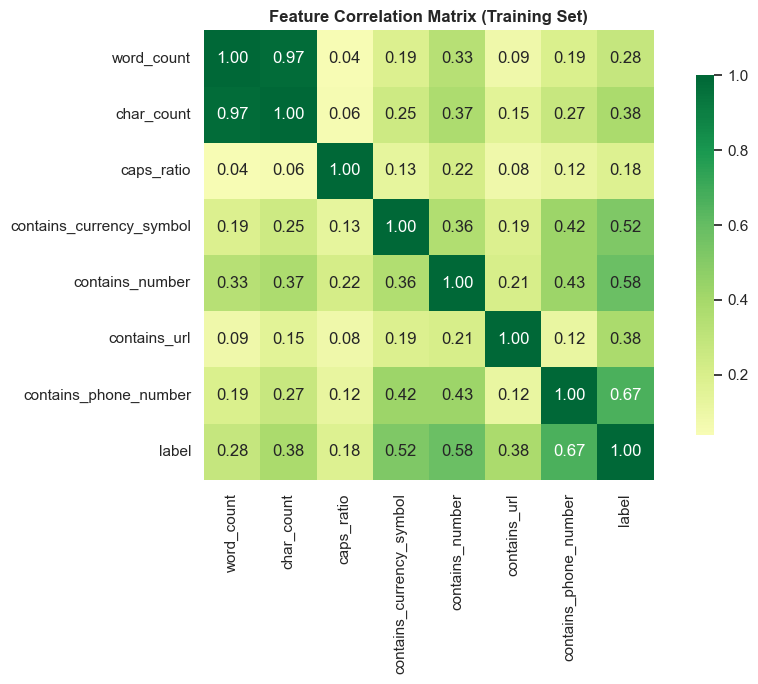

In [10]:
feature_cols = ['word_count', 'char_count', 'caps_ratio',
                'contains_currency_symbol', 'contains_number',
                'contains_url', 'contains_phone_number', 'label']

corr = df_train[feature_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Training Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('../readme-resources/feature_correlation.png', bbox_inches='tight')
plt.show()